In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'


from gsmo.hist_features_uni import extract_embeddings
from gsmo.utils import *
from gsmo import GSMO, GSMOConfig
from PIL import Image
import pandas as pd
import numpy as np
import scanpy as sc
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
Image.MAX_IMAGE_PIXELS = None
Image.MAX_IMAGE_PIXELS = None
import torch
import random

seed=100
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("CUDA is available. GPU:", torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print("CUDA is not available. Using CPU.")


CUDA is available. GPU: NVIDIA GeForce RTX 3090


In [2]:
import os
os.chdir('data/fivemodal')

In [3]:
rna = sc.read('scRNA.h5ad')
spatial_coords = rna.obs[['x', 'y']].copy()
spatial_coords = spatial_coords.values

rna = sc.read('preprocessed_rna.h5ad')
rna_feat = rna.X.toarray() if scipy.sparse.issparse(rna.X) else rna.X

H3K27me3 = sc.read('preprocessed_H3K27me3.h5ad')
H3K27me3_feat = H3K27me3.obsm['X_lsi'][:, :1024]

atac = sc.read('preprocessed_atac.h5ad')
atac_feat = atac.obsm['X_lsi'][:, :1024]

H3K27ac = sc.read('preprocessed_H3K27ac.h5ad')
H3K27ac_feat = H3K27ac.obsm['X_lsi'][:, :1024]


protein = sc.read('preprocessed_protein.h5ad')
protein_feat = protein.X.toarray() if scipy.sparse.issparse(protein.X) else protein.X



In [ ]:
features_dict = {
        'rna': rna_feat,        
        'protein': protein_feat,      
        'atac': atac_feat,       
        'h3k27me3': H3K27me3_feat,   
        'h3k27ac': H3K27ac_feat   
    }

initial_weights = [1.0, 1.0, 1.0, 1.0, 1.0] 



cfg = GSMOConfig

model = GSMO(features_dict, spatial_coords=spatial_coords, device=device, cfg=cfg,
            trainable_weights=True, initial_weights=initial_weights)

model.load_state_dict(torch.load("best_model.pth"))

/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


<All keys matched successfully>

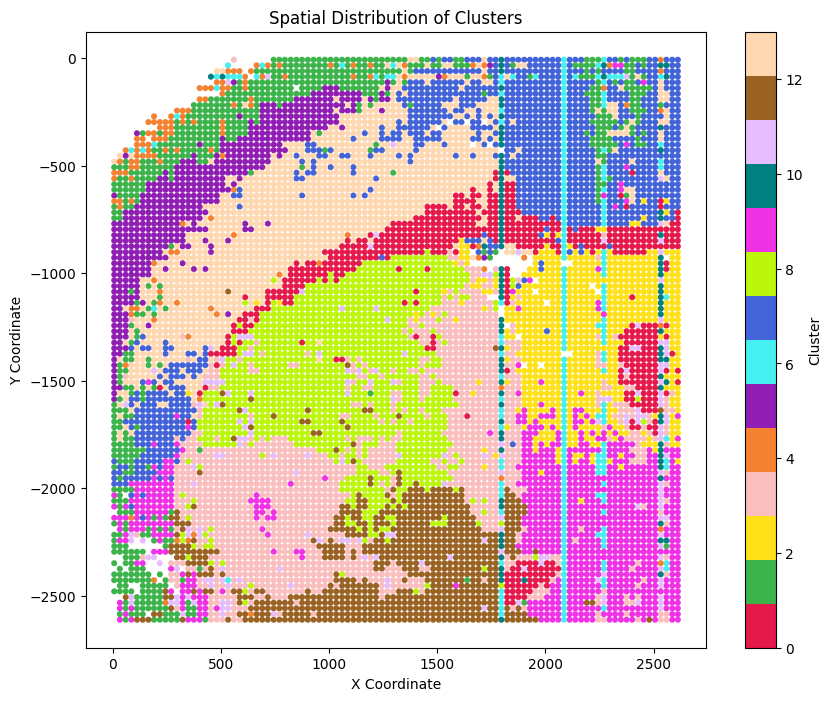

In [ ]:
# visualization of clustering results
from matplotlib.colors import ListedColormap

plot_color = ['#e6194b', '#3cb44b', '#ffe119', '#fabebe', '#f58231', '#911eb4', '#46f0f0', '#4363d8', 
              '#bcf60c', '#f032e6', '#008080', '#e6beff', '#9a6324', '#ffd8b1', '#800000', '#aaffc3', '#808000', 
              '#000075', '#000000', '#808080', '#ffffff', '#fffac8', '#D1D1D1']


rna1 = sc.read('scRNA.h5ad')


assert 'x' in rna1.obs.columns and 'y' in rna1.obs.columns, "The RNA data is missing spatial coordinates or has an incorrect format. Please check the data."

rna_locs = rna1.obs[['x', 'y']].copy()

assert rna_locs is not None and rna_locs.shape[1] == 2, "The RNA data is missing spatial coordinates or has an incorrect format. Please check the data."

clusters = model.cluster_kmeans(n_clusters=14)
rna_locs_df = pd.DataFrame(rna_locs, columns=['x', 'y'])  
rna_locs_df['cluster'] = clusters  

num_clusters = len(np.unique(clusters))

if num_clusters > len(plot_color):
    raise ValueError(f"Cluster number {num_clusters} exceeds the number of colors available in the custom palette {len(plot_color)}.")

cmap = ListedColormap(plot_color[:num_clusters])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(rna_locs_df['y'], -rna_locs_df['x'], c=rna_locs_df['cluster'], cmap=cmap, s=11)
plt.colorbar(scatter, label="Cluster")
plt.title("Spatial Distribution of Clusters")
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()



<Figure size 800x600 with 0 Axes>

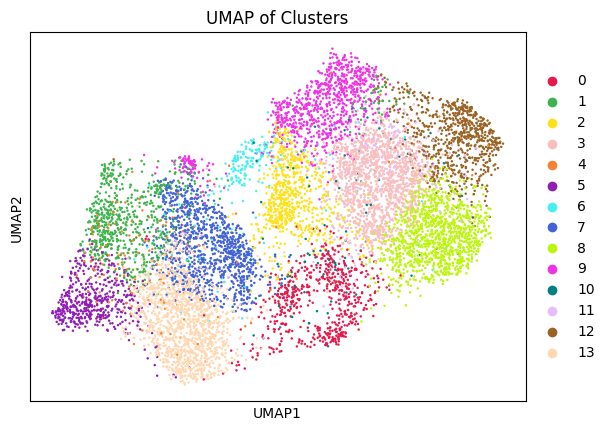

In [7]:
from matplotlib.colors import ListedColormap


rna = sc.read('scRNA.h5ad')

fused_emb = model.get_embeddings()
rna.obsm['X_fused'] = fused_emb

clusters = model.cluster_kmeans(n_clusters=14)
rna.obs['cluster'] = clusters.astype(str)

sc.pp.neighbors(rna, use_rep='X_fused')  
sc.tl.umap(rna)

num_clusters = len(np.unique(clusters))

if num_clusters > len(plot_color):
    raise ValueError(f"Cluster number {num_clusters} exceeds the number of colors available in the custom palette {len(plot_color)}.")

cmap = ListedColormap(plot_color[:num_clusters])

plt.figure(figsize=(8, 6))
sc.pl.umap(rna, color='cluster', palette=plot_color[:num_clusters], title='UMAP of Clusters', show=True)


In [8]:
# two unsupervised metrics

from sklearn.metrics import pairwise_distances
import numpy as np
from tqdm import tqdm

def compute_jaccard_similarity(Z_m, Z_e, k=50):

    dist_m = pairwise_distances(Z_m)
    dist_e = pairwise_distances(Z_e)
    
    n = Z_m.shape[0]
    jaccard_scores = []

    for i in tqdm(range(n), desc="Calculating Jaccard similarities"):
        neighbors_m = set(np.argsort(dist_m[i])[1:k+1])  # exclude self
        neighbors_e = set(np.argsort(dist_e[i])[1:k+1])
        intersection = len(neighbors_m & neighbors_e)
        union = len(neighbors_m | neighbors_e)
        jaccard = intersection / union if union > 0 else 0.0
        jaccard_scores.append(jaccard)

    return np.array(jaccard_scores), np.mean(jaccard_scores)


import squidpy as sq

def compute_morans_I(labels, spatial_coords, label_name="cluster_label"):

    adata = sc.AnnData(X=np.zeros((len(labels), 1)))  # dummy
    adata.obs[label_name] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)

    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    sq.gr.spatial_autocorr(adata, mode="moran", genes=label_name, attr="obs")

    moran_result = adata.uns["moranI"].loc[label_name, "I"]
    return moran_result


fused_embeddings = model.get_embeddings()


# 1. Jaccard
jaccard_all, jaccard_mean = compute_jaccard_similarity(rna_feat, fused_embeddings, k=50)
print(f"Mean Jaccard RNA Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(atac_feat, fused_embeddings, k=50)
print(f"Mean Jaccard atac Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(H3K27me3_feat, fused_embeddings, k=50)
print(f"Mean Jaccard H3K27me3 Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(H3K27ac_feat, fused_embeddings, k=50)
print(f"Mean Jaccard H3K27ac Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(protein_feat, fused_embeddings, k=50)
print(f"Mean Jaccard protein Similarity: {jaccard_mean:.4f}")

cluster_labels = model.cluster_kmeans(n_clusters=14)
morans_I = compute_morans_I(cluster_labels, spatial_coords)
print(f"Moran's I score: {morans_I:.4f}")

/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
Calculating Jaccard similarities: 100%|██████████| 9686/9686 [00:06<00:00, 1563.12it/s]


Mean Jaccard RNA Similarity: 0.0086


Calculating Jaccard similarities: 100%|██████████| 9686/9686 [00:06<00:00, 1536.88it/s]


Mean Jaccard atac Similarity: 0.0066


Calculating Jaccard similarities: 100%|██████████| 9686/9686 [00:06<00:00, 1552.87it/s]


Mean Jaccard H3K27me3 Similarity: 0.0021


Calculating Jaccard similarities: 100%|██████████| 9686/9686 [00:06<00:00, 1548.98it/s]


Mean Jaccard H3K27ac Similarity: 0.0037


Calculating Jaccard similarities: 100%|██████████| 9686/9686 [00:06<00:00, 1559.17it/s]


Mean Jaccard protein Similarity: 0.0388
Moran's I score: 0.6463


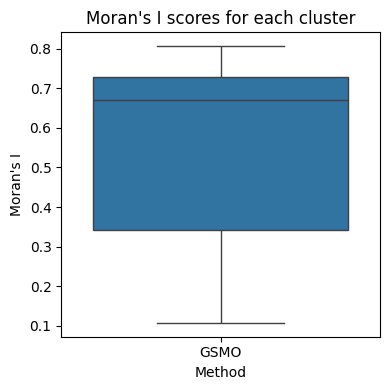

   cluster   moran_I method
0        0  0.668453   GSMO
1        1  0.601840   GSMO
2        2  0.714237   GSMO
3        3  0.662836   GSMO
4        4  0.256260   GSMO
5        5  0.806736   GSMO
6        6  0.239333   GSMO
7        7  0.671713   GSMO
8        8  0.758789   GSMO
9        9  0.706064   GSMO
10      10  0.184133   GSMO
11      11  0.106971   GSMO
12      12  0.748184   GSMO
13      13  0.733917   GSMO


In [10]:
# box plot of moran's I

import squidpy as sq
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_morans_I_per_method(labels, spatial_coords, method_name="GSMO"):
    adata = sc.AnnData(X=np.zeros((len(labels), 1)))
    adata.obs["cluster_label"] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)

    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    moran_scores = []
    unique_labels = np.unique(labels)

    for label in unique_labels:
        binary_vector = (labels == label).astype(int)
        adata.obs["tmp_binary"] = binary_vector

        sq.gr.spatial_autocorr(adata, mode="moran", genes="tmp_binary", attr="obs")
        I_score = adata.uns["moranI"].loc["tmp_binary", "I"]
        moran_scores.append({
            "cluster": str(label),
            "moran_I": I_score,
            "method": method_name
        })

    df_moran = pd.DataFrame(moran_scores)

    plt.figure(figsize=(4, 4))
    sns.boxplot(data=df_moran, x="method", y="moran_I")
    plt.title("Moran's I scores for each cluster")
    plt.ylabel("Moran's I")
    plt.xlabel("Method")
    plt.tight_layout()
    plt.show()

    return df_moran

morans_I_df = compute_morans_I_per_method(cluster_labels, spatial_coords, method_name="GSMO")
print(morans_I_df)
